In [1]:
import cv2
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

PROC = Path('../data/processed')
MASK = Path('../data/masks')
CLASSES = ['glioma', 'meningioma', 'pituitary', 'notumor']

print("Processed dir exists:", PROC.exists())
print("First processed image:", next(PROC.glob('**/*.png')))

Processed dir exists: True
First processed image: ..\data\processed\Testing\glioma\Te-gl_1.png


In [14]:
def make_brain_mask(img_gray):
    """
    Robust brain mask with hole-filling.
    """
    _, mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Stronger initial close to bridge larger gaps in bright brain tissue
    kernel_big = np.ones((11, 11), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_big, iterations=3)
    
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        return np.ones_like(img_gray, dtype=np.uint8)
    
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    brain_mask = (labels == largest_label).astype(np.uint8)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_CLOSE, kernel_big, iterations=2)
    
    # Hole-filling: force interior black regions to fill in
    brain_mask_filled = brain_mask.copy()
    contours, _ = cv2.findContours(brain_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cv2.drawContours(brain_mask_filled, contours, -1, 1, thickness=cv2.FILLED)
    
    return brain_mask_filled


# Test
test_path = next((PROC / 'Training' / 'glioma').glob('*.png'))
test_img = cv2.imread(str(test_path), cv2.IMREAD_GRAYSCALE)
test_mask = make_brain_mask(test_img)
print(f"Image shape: {test_img.shape}")
print(f"Mask shape:  {test_mask.shape}")
print(f"Mask values: {sorted(np.unique(test_mask))}")
print(f"Brain pixels: {test_mask.sum()} / {test_mask.size} ({100*test_mask.sum()/test_mask.size:.1f}%)")

Image shape: (224, 224)
Mask shape:  (224, 224)
Mask values: [np.uint8(0), np.uint8(1)]
Brain pixels: 42547 / 50176 (84.8%)


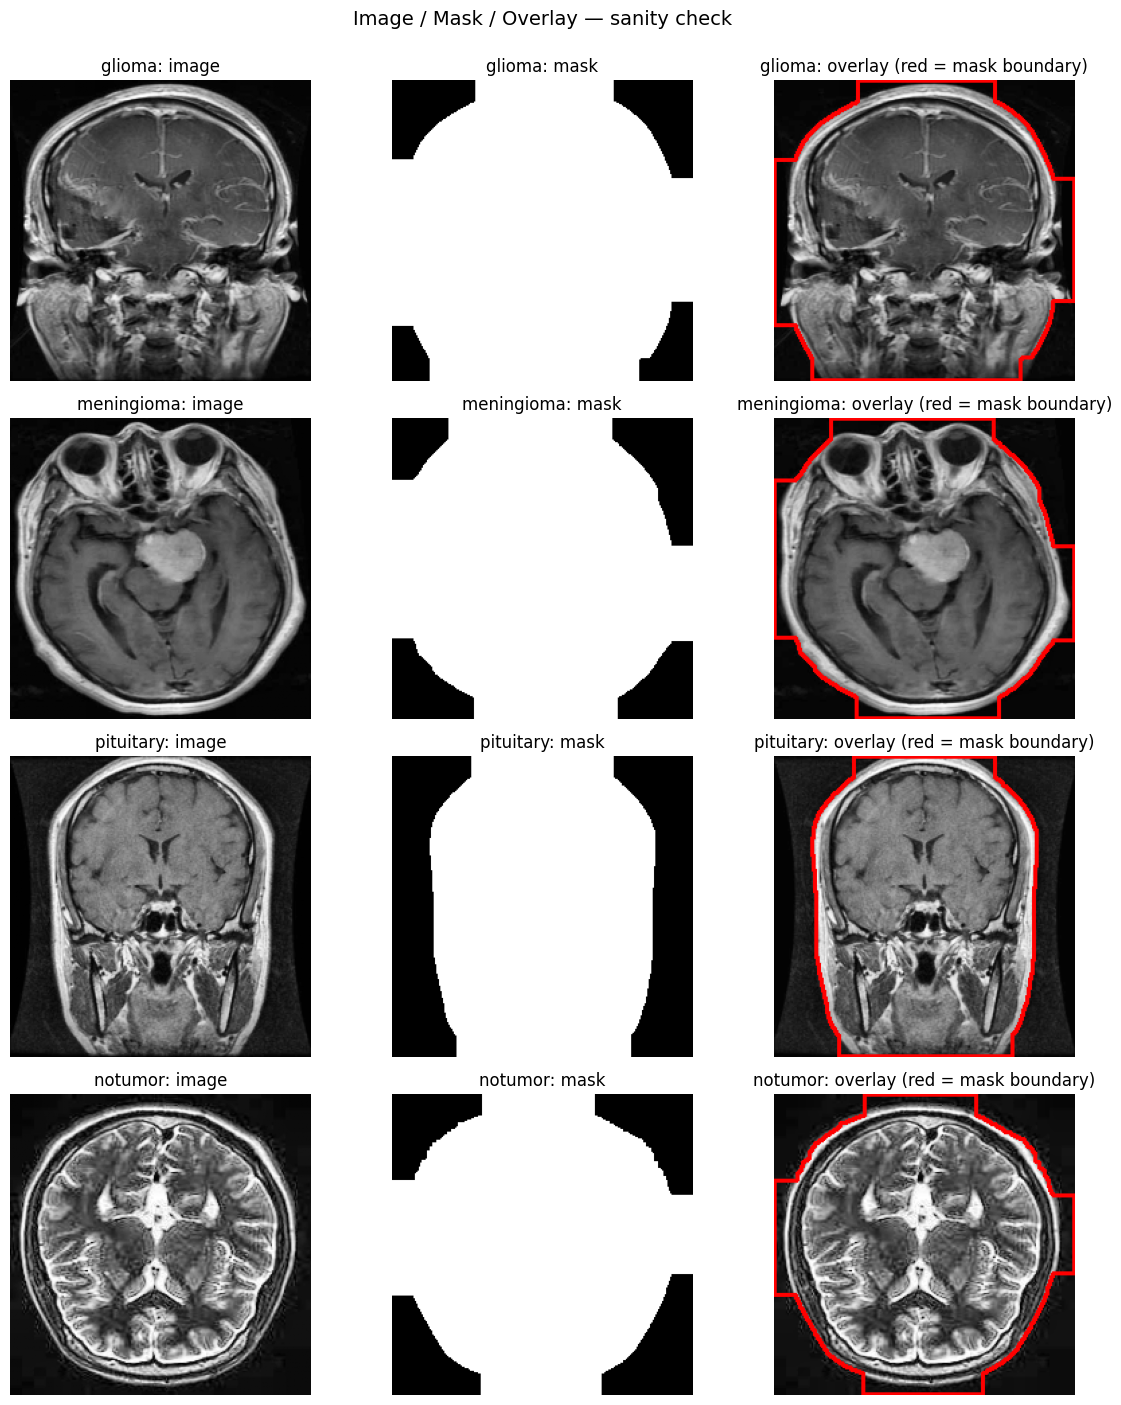

In [15]:
fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for row, c in enumerate(CLASSES):
    sample = next((PROC / 'Training' / c).glob('*.png'))
    img = cv2.imread(str(sample), cv2.IMREAD_GRAYSCALE)
    mask = make_brain_mask(img)
    
    # Create overlay: image with mask outline in red
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)
    
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f"{c}: image"); axes[row, 0].axis('off')
    
    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].set_title(f"{c}: mask"); axes[row, 1].axis('off')
    
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f"{c}: overlay (red = mask boundary)"); axes[row, 2].axis('off')

plt.suptitle("Image / Mask / Overlay — sanity check", fontsize=14, y=1.00)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig('../outputs/mask_qa.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
print("Generating masks for all images...")
print()

count = 0
for split in ['Training', 'Testing']:
    for c in CLASSES:
        in_dir = PROC / split / c
        files = list(in_dir.glob('*.png'))
        
        for f in tqdm(files, desc=f'{split}/{c}'):
            img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            
            mask = make_brain_mask(img)
            
            out_path = MASK / split / c / f'{f.stem}_mask.png'
            out_path.parent.mkdir(parents=True, exist_ok=True)
            
            cv2.imwrite(str(out_path), mask * 255)
            count += 1

print(f"\nDone! Generated {count} masks.")

Generating masks for all images...



Training/glioma:   0%|          | 0/1400 [00:00<?, ?it/s]

Training/meningioma:   0%|          | 0/1400 [00:00<?, ?it/s]

Training/pituitary:   0%|          | 0/1400 [00:00<?, ?it/s]

Training/notumor:   0%|          | 0/1400 [00:00<?, ?it/s]

Testing/glioma:   0%|          | 0/400 [00:00<?, ?it/s]

Testing/meningioma:   0%|          | 0/400 [00:00<?, ?it/s]

Testing/pituitary:   0%|          | 0/400 [00:00<?, ?it/s]

Testing/notumor:   0%|          | 0/400 [00:00<?, ?it/s]


Done! Generated 7200 masks.


In [17]:
print(f"{'Split':<10} {'Class':<15} {'Count':<10}")
print("-" * 40)
for split in ['Training', 'Testing']:
    for c in CLASSES:
        n = len(list((MASK / split / c).glob('*.png')))
        print(f"{split:<10} {c:<15} {n:<10}")

print("\nVerifying mask format...")
sample_mask = cv2.imread(str(next(MASK.glob('**/*.png'))), cv2.IMREAD_GRAYSCALE)
unique_values = sorted(np.unique(sample_mask))
print(f"Sample mask values: {unique_values} (expected [0, 255])")
print(f"Sample mask shape: {sample_mask.shape}")

Split      Class           Count     
----------------------------------------
Training   glioma          1400      
Training   meningioma      1400      
Training   pituitary       1400      
Training   notumor         1400      
Testing    glioma          400       
Testing    meningioma      400       
Testing    pituitary       400       
Testing    notumor         400       

Verifying mask format...
Sample mask values: [np.uint8(0), np.uint8(255)] (expected [0, 255])
Sample mask shape: (224, 224)


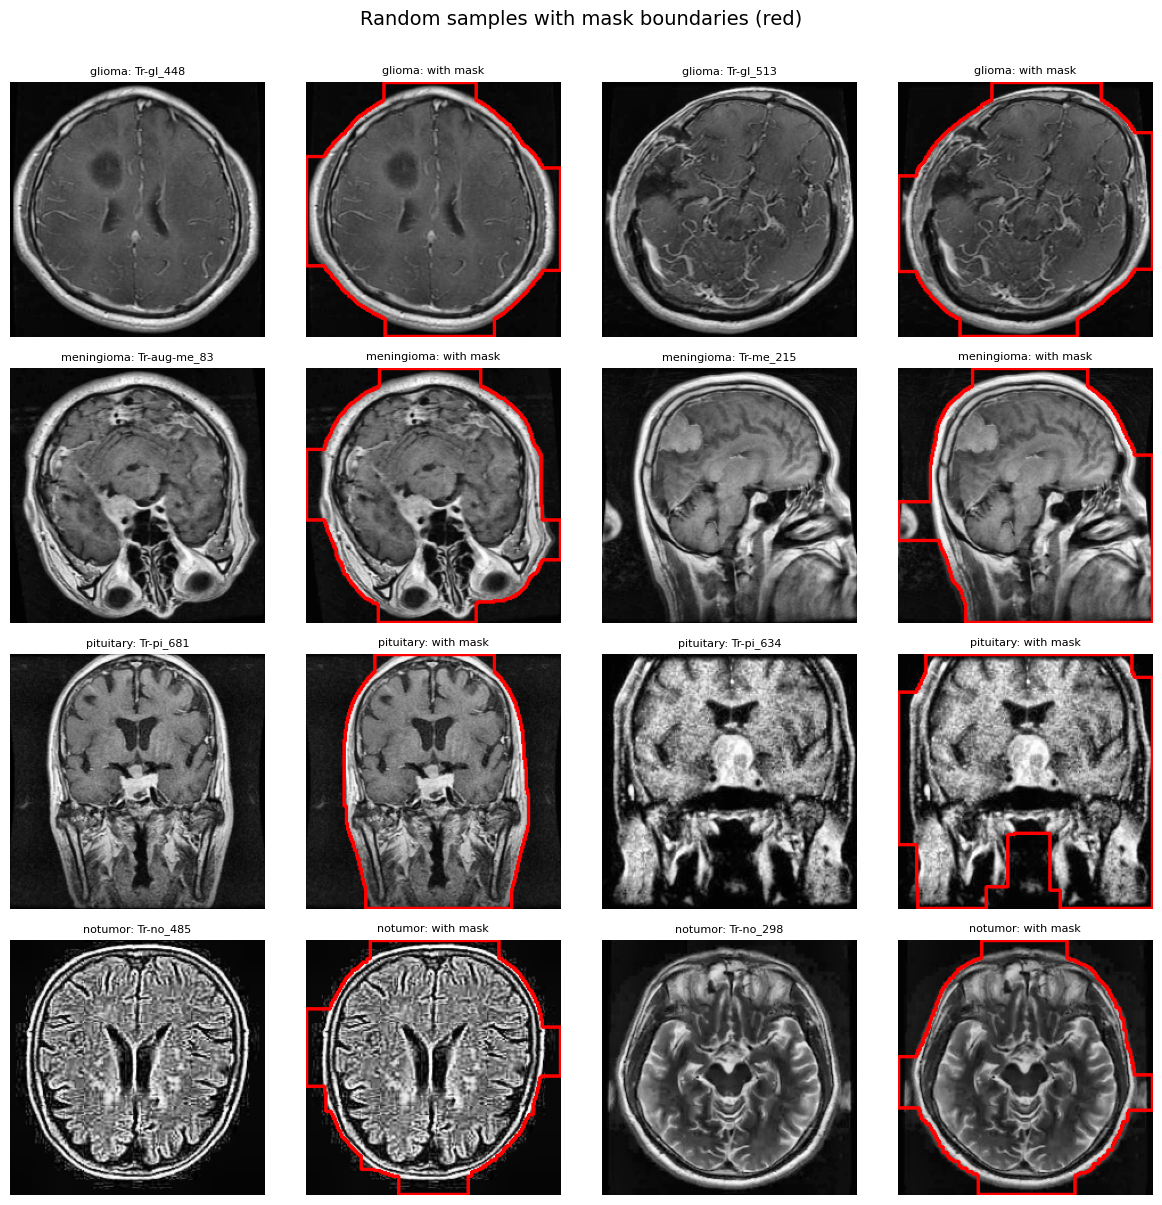

In [18]:
import random
random.seed(0)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, c in enumerate(CLASSES):
    files = random.sample(list((PROC / 'Training' / c).glob('*.png')), 2)
    for i, f in enumerate(files):
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        mask_path = MASK / 'Training' / c / f'{f.stem}_mask.png'
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        axes[row, i*2].imshow(img, cmap='gray')
        axes[row, i*2].set_title(f"{c}: {f.stem[:15]}", fontsize=8)
        axes[row, i*2].axis('off')
        
        overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        contours, _ = cv2.findContours((mask > 0).astype(np.uint8), 
                                        cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)
        axes[row, i*2+1].imshow(overlay)
        axes[row, i*2+1].set_title(f"{c}: with mask", fontsize=8)
        axes[row, i*2+1].axis('off')

plt.suptitle("Random samples with mask boundaries (red)", fontsize=14, y=1.00)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.savefig('../outputs/mask_random_samples.png', dpi=120, bbox_inches='tight')
plt.show()